In [1]:
import numpy as np  
import xarray as xr
                

In [2]:
slice_str = "2024-07-16 00:00:00, 2024-07-16 23:00:00"
slice_tuple = tuple(slice_str.split(", "))

data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))

time_dim = 'valid_time'
data_era_10min = data_era.resample({time_dim: '10min'}).interpolate('linear')
data_era_10_min = data_era_10min.sel(valid_time=slice(*slice_tuple))

data_era_30min = data_era.resample({time_dim: '1min'}).interpolate('linear')
data_era_1_min = data_era_30min.sel(valid_time=slice(*slice_tuple))

In [3]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

NameError: name 'plt' is not defined

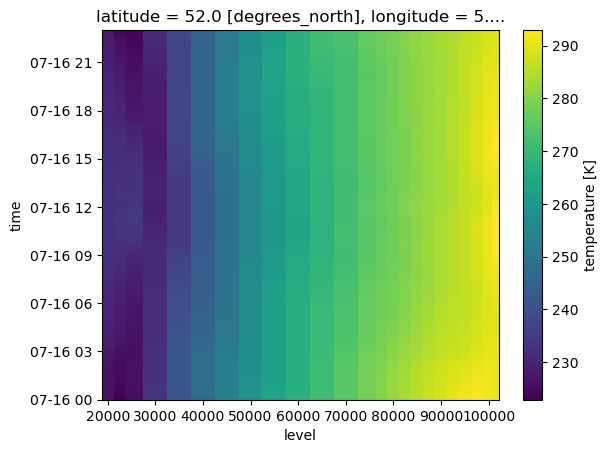

In [4]:
data_era_1_min.temperature.plot()
plt.show()

In [5]:


data_era_10 = data_era.resample({time_dim: '1min'}).interpolate('quadratic')
data_era_quadratic = data_era_10min.sel(valid_time=slice(*slice_tuple))

data_era_30 = data_era.resample({time_dim: '1min'}).interpolate('cubic')
data_era_cubic = data_era_30.sel(valid_time=slice(*slice_tuple))

data_era_40 = data_era.resample({time_dim: '1min'}).interpolate('slinear')
data_era_slinear = data_era_40.sel(valid_time=slice(*slice_tuple))

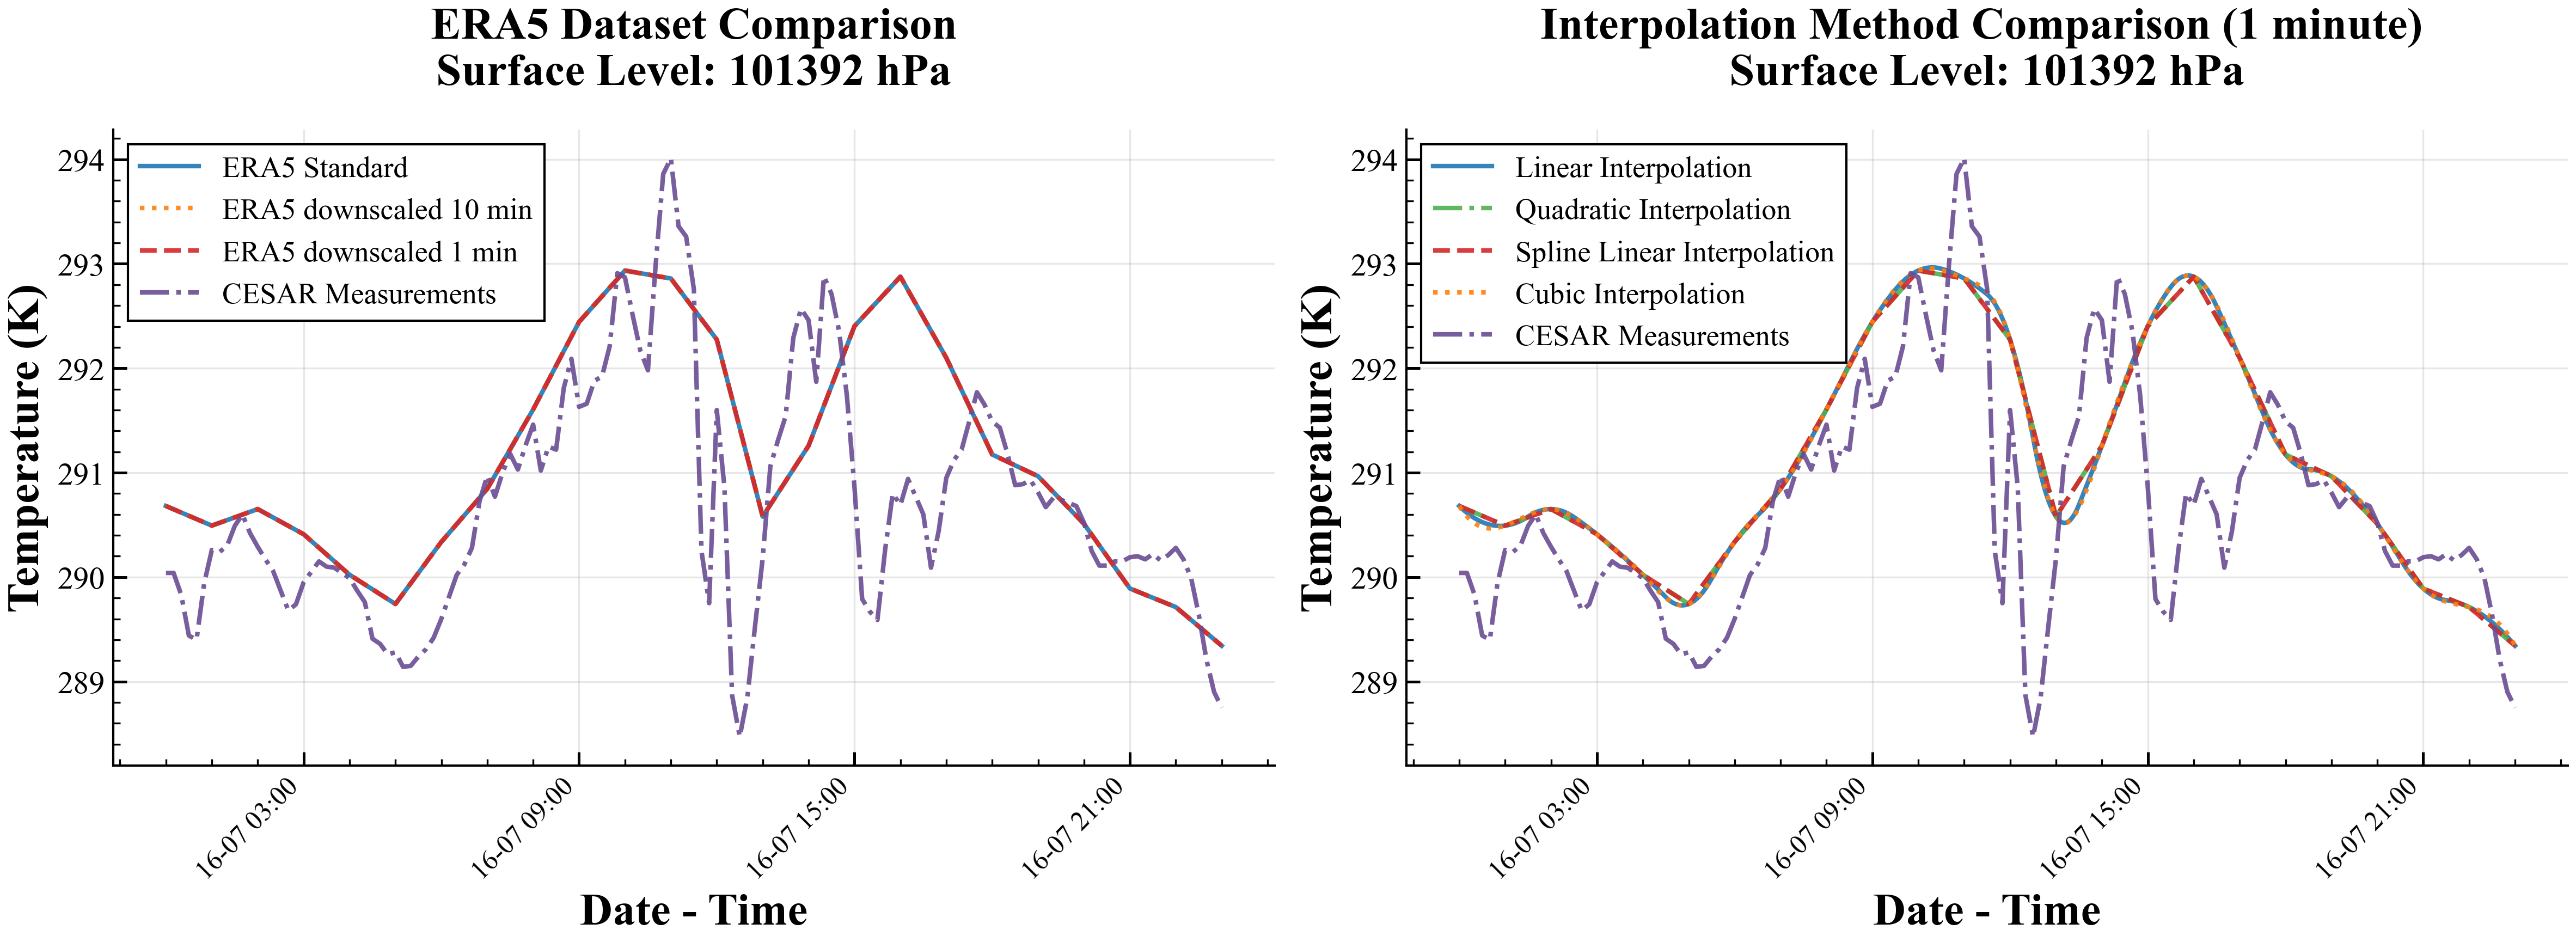

In [16]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # Adjust as needed

# Scientific publication-quality styling
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 20 * SCALE_FACTOR,
    'axes.titlesize': 20 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 14 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend
    'legend.fontsize': 13 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',
})

# Create figure with two horizontal subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Get surface level
surface = data_era_30.level.values[0]

# ==================== SUBPLOT 1: Different ERA5 Datasets ====================
# Scientific color palette for different datasets
colors1 = {
    'era5': '#1f77b4',      # Blue
    'era5_30': '#d62728',   # Red  
    'era5_10': '#ff7f0e' ,   # Orange
   'measurements':'#6a4c93'
}

# Data for first subplot
temp_era = data_era.temperature.sel(level=surface)
temp_era_1_min = data_era_1_min.temperature.sel(level=surface)  
temp_era_10 = data_era_10_min.temperature.sel(level=surface)

# Plot with scientific styling
line1_1 = temp_era.plot(ax=ax1, 
                       color=colors1['era5'], 
                       label='ERA5 Standard',
                       linestyle='-', 
                       linewidth=2.0 * SCALE_FACTOR,
                       alpha=0.9,
                       add_legend=False)



line1_3 = temp_era_10.plot(ax=ax1,
                          color=colors1['era5_10'], 
                          label='ERA5 downscaled 10 min',
                          linestyle=':', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)
line1_2 = temp_era_1_min.plot(ax=ax1,
                          color=colors1['era5_30'], 
                          label='ERA5 downscaled 1 min',
                          linestyle='--', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)

line_meteo = measurements_used.TA002.plot(ax=ax1,
                          color=colors1['measurements'], 
                          label='CESAR Measurements',
                          linestyle='-.', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)

# Styling for subplot 1
ax1.set_ylabel('Temperature (K)', fontweight='bold')
ax1.set_xlabel('Date - Time', fontweight='bold')
ax1.set_title(f'ERA5 Dataset Comparison\nSurface Level: {surface:.0f} hPa',
              fontweight='bold', pad=20 * SCALE_FACTOR)

ax1.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax1.set_axisbelow(True)
ax1.minorticks_on()

legend1 = ax1.legend(loc='best',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

ax1.tick_params(which='major', length=6 * SCALE_FACTOR, width=1.2 * SCALE_FACTOR)
ax1.tick_params(which='minor', length=3 * SCALE_FACTOR, width=0.8 * SCALE_FACTOR)

# ==================== SUBPLOT 2: Interpolation Methods ====================
# Scientific color palette for interpolation methods
colors2 = {
    'era5_10': '#1f77b4',      # Blue - 10-level
    'slinear': '#d62728',      # Red - spline linear
    'cubic': '#ff7f0e', 
    'quadratic': '#4caf50'       # Orange - cubic
}

# Data for second subplot
temp_era_10_interp = data_era_10.temperature.sel(level=surface)
temp_era_quadratic = data_era_quadratic.temperature.sel(level=surface)
temp_era_slinear = data_era_slinear.temperature.sel(level=surface)
temp_era_cubic = data_era_cubic.temperature.sel(level=surface)

# Plot with scientific styling - comparing interpolation methods
line2_1 = temp_era_10_interp.plot(ax=ax2, 
                                 color=colors2['era5_10'], 
                                 label='Linear Interpolation',
                                 linestyle='-', 
                                 linewidth=2.0 * SCALE_FACTOR,
                                 alpha=0.9,
                                 add_legend=False)
line_3 = temp_era_quadratic.plot(ax=ax2, 
                                 color=colors2['quadratic'], 
                                 label='Quadratic Interpolation',
                                 linestyle='-.', 
                                 linewidth=2.0 * SCALE_FACTOR,
                                 alpha=0.9,
                                 add_legend=False)

line2_2 = temp_era_slinear.plot(ax=ax2,
                               color=colors2['slinear'], 
                               label='Spline Linear Interpolation',
                               linestyle='--', 
                               linewidth=2.0 * SCALE_FACTOR,
                               alpha=0.9,
                               add_legend=False)

line2_3 = temp_era_cubic.plot(ax=ax2,
                             color=colors2['cubic'], 
                             label='Cubic Interpolation',
                             linestyle=':', 
                             linewidth=2.0 * SCALE_FACTOR,
                             alpha=0.9,
                             add_legend=False)
line_meteo = measurements_used.TA002.plot(ax=ax2,
                          color=colors1['measurements'], 
                          label='CESAR Measurements',
                          linestyle='-.', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)

# Styling for subplot 2
ax2.set_ylabel('Temperature (K)', fontweight='bold')
ax2.set_xlabel('Date - Time', fontweight='bold')
ax2.set_title(f'Interpolation Method Comparison (1 minute) \nSurface Level: {surface:.0f} hPa',
              fontweight='bold', pad=20 * SCALE_FACTOR)

ax2.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax2.set_axisbelow(True)
ax2.minorticks_on()

legend2 = ax2.legend(loc='best',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

ax2.tick_params(which='major', length=6 * SCALE_FACTOR, width=1.2 * SCALE_FACTOR)
ax2.tick_params(which='minor', length=3 * SCALE_FACTOR, width=0.8 * SCALE_FACTOR)

# ==================== SHARED FORMATTING - HIGH TEMPORAL RESOLUTION ====================
# Format x-axis for both subplots with increased temporal resolution
for ax in [ax1, ax2]:
    try:
        # Get the first data variable to check if it's time-based
        first_data = list(ax.get_lines())[0].get_xdata()
        if hasattr(first_data, 'dtype') and 'datetime' in str(first_data.dtype):
            # High temporal resolution formatting
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
            ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))  # Major ticks every 6 hours
            
            # Minor ticks for even finer resolution
            ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))  # Minor ticks every hour
            
            # Rotate labels for better readability with more frequent ticks
            plt.setp(ax.xaxis.get_majorticklabels(), 
                    rotation=45, 
                    ha='right', 
                    fontsize=12*SCALE_FACTOR)
        else:
            # For non-datetime data, increase tick frequency
            ax.locator_params(axis='x', nbins=12)  # More x-axis ticks
    except:
        # Fallback: increase number of ticks
        ax.locator_params(axis='x', nbins=15)



# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3, top=0.85)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults after plotting
plt.rcParams.update(plt.rcParamsDefault)

In [7]:
data_era_30.temperature.sel(level=surface).values

array([290.68054199, 290.66897794, 290.65779231, ..., 289.36835382,
       289.35566213, 289.34265137], shape=(1381,))

In [8]:
data_era.temperature.sel(level=surface).values

array([290.68054, 290.4928 , 290.65125, 290.4104 , 290.02246, 289.7423 ,
       290.33716, 290.84473, 291.60498, 292.443  , 292.9348 , 292.85913,
       292.27368, 290.5791 , 291.2577 , 292.40308, 292.8766 , 292.099  ,
       291.17346, 290.96533, 290.50934, 289.89056, 289.71265, 289.34265],
      dtype=float32)

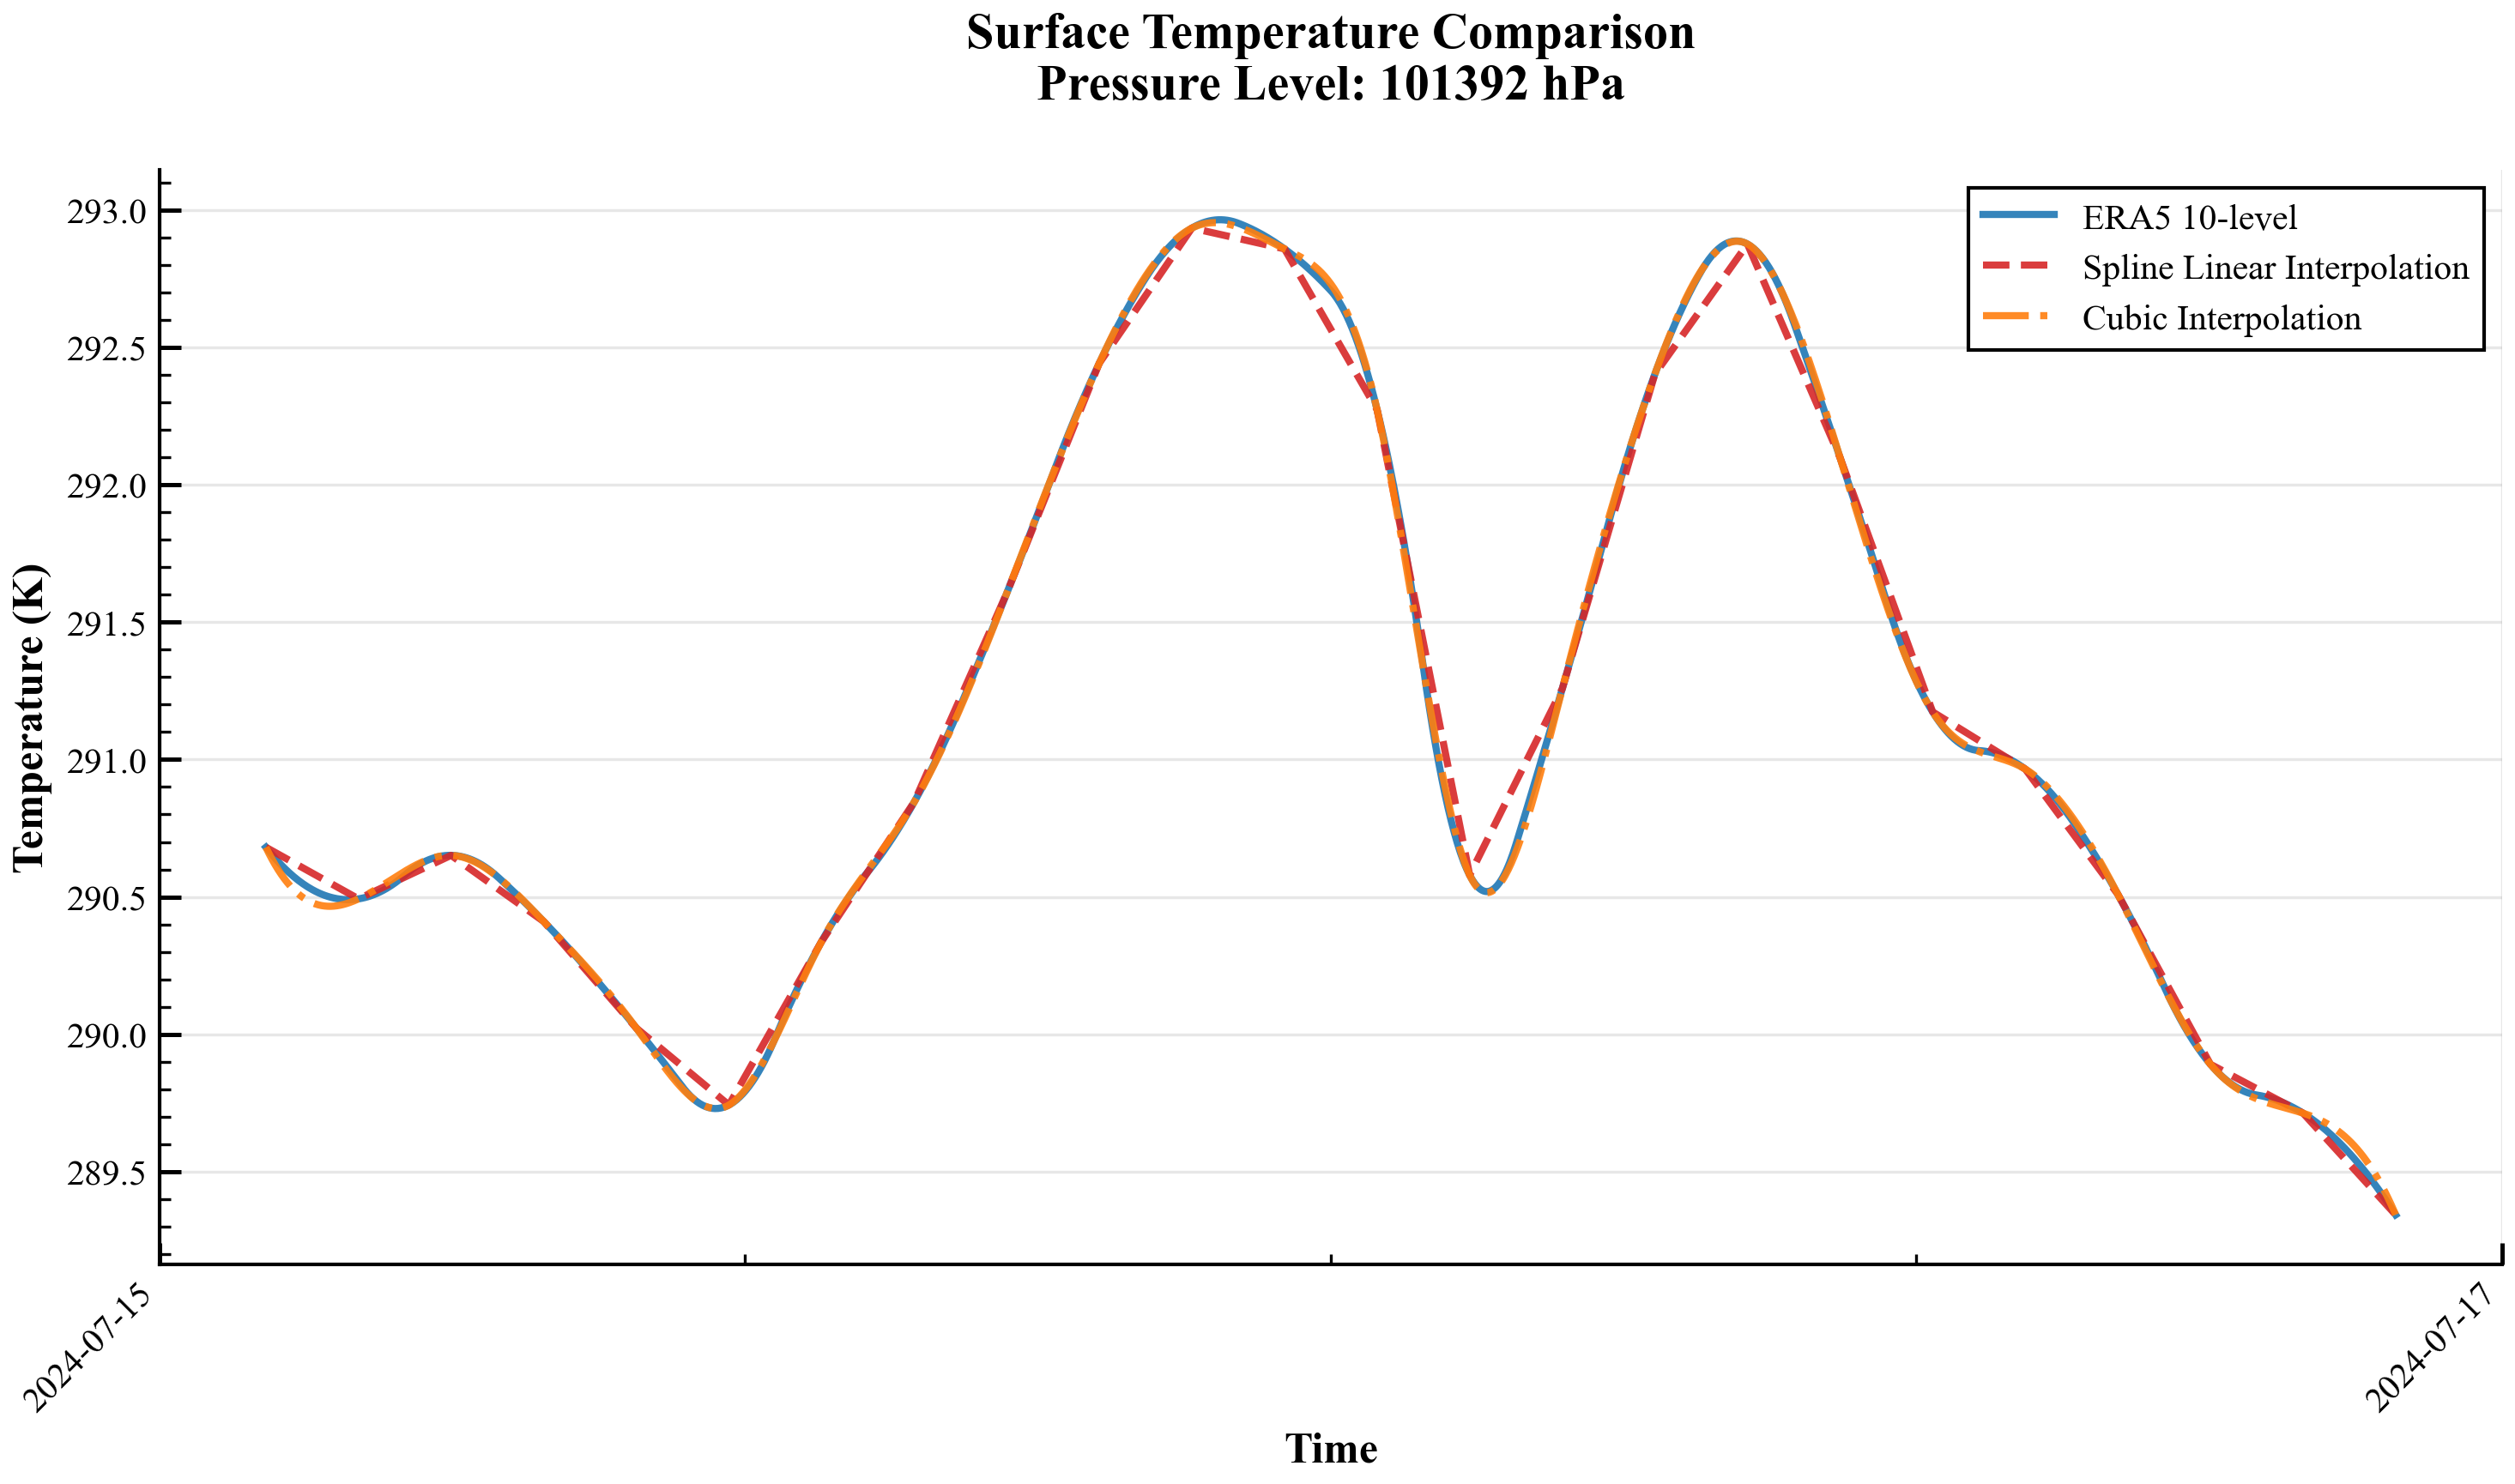

In [9]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # Adjust as needed

# Scientific publication-quality styling
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',
})

# Create enhanced figure
fig, ax = plt.subplots(1, 1, figsize=(10 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly) for interpolation methods
colors = {
    'era5_10': '#1f77b4',      # Blue - 10-level
    'slinear': '#d62728',      # Red - spline linear
    'cubic': '#ff7f0e',        # Orange - cubic
    'original': '#2ca02c'      # Green - if you want to add original later
}

# Get surface level
surface = data_era_30.level.values[0]

# Enhanced plotting with proper labels and styling for interpolation comparison
temp_era_10 = data_era_10.temperature.sel(level=surface)
temp_era_slinear = data_era_slinear.temperature.sel(level=surface)
temp_era_cubic = data_era_cubic.temperature.sel(level=surface)

# Plot with scientific styling - comparing interpolation methods
line1 = temp_era_10.plot(ax=ax, 
                        color=colors['era5_10'], 
                        label='ERA5 10-level',
                        linestyle='-', 
                        linewidth=2.0 * SCALE_FACTOR,
                        alpha=0.9,
                        add_legend=False)

line2 = temp_era_slinear.plot(ax=ax,
                             color=colors['slinear'], 
                             label='Spline Linear Interpolation',
                             linestyle='--', 
                             linewidth=2.0 * SCALE_FACTOR,
                             alpha=0.9,
                             add_legend=False)

line3 = temp_era_cubic.plot(ax=ax,
                           color=colors['cubic'], 
                           label='Cubic Interpolation',
                           linestyle='-.', 
                           linewidth=2.0 * SCALE_FACTOR,
                           alpha=0.9,
                           add_legend=False)

# Scientific axis labels with units
ax.set_ylabel('Temperature (K)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title(f'Surface Temperature Comparison\nPressure Level: {surface:.0f} hPa',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning
legend = ax.legend(loc='best',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)

# Tick parameters
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Format x-axis if it's a time series
try:
    if hasattr(temp_era.coords[temp_era.dims[0]], 'dtype') and 'datetime' in str(temp_era.coords[temp_era.dims[0]].dtype):
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), 
                rotation=45, 
                ha='right', 
                fontsize=10*SCALE_FACTOR)
except:
    pass

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults after plotting
plt.rcParams.update(plt.rcParamsDefault)

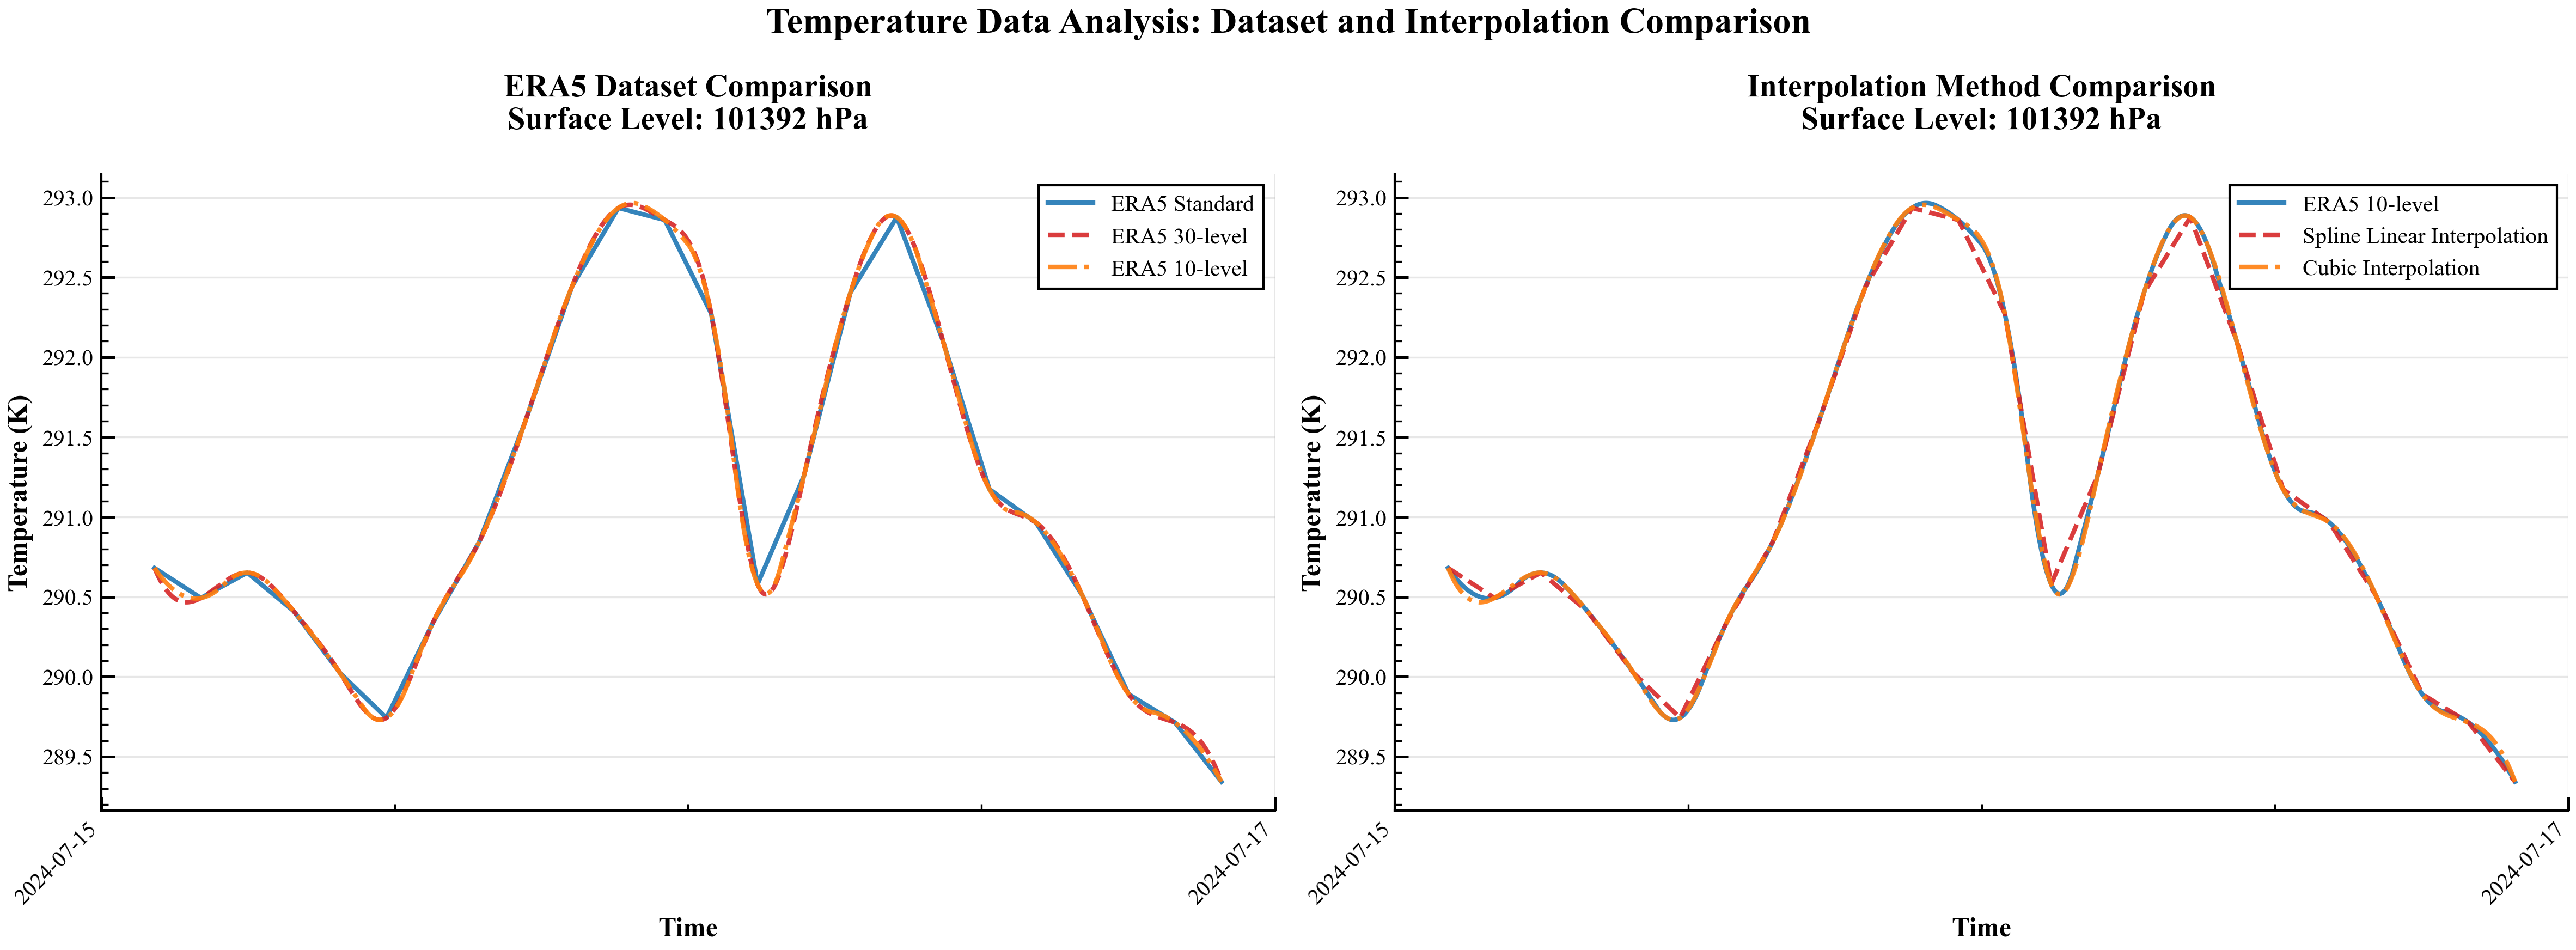

In [10]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # Adjust as needed

# Scientific publication-quality styling
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',
})

# Create figure with two horizontal subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Get surface level
surface = data_era_30.level.values[0]

# ==================== SUBPLOT 1: Different ERA5 Datasets ====================
# Scientific color palette for different datasets
colors1 = {
    'era5': '#1f77b4',      # Blue
    'era5_30': '#d62728',   # Red  
    'era5_10': '#ff7f0e'    # Orange
}

# Data for first subplot
temp_era = data_era.temperature.sel(level=surface)
temp_era_30 = data_era_30.temperature.sel(level=surface)  
temp_era_10 = data_era_10.temperature.sel(level=surface)

# Plot with scientific styling
line1_1 = temp_era.plot(ax=ax1, 
                       color=colors1['era5'], 
                       label='ERA5 Standard',
                       linestyle='-', 
                       linewidth=2.0 * SCALE_FACTOR,
                       alpha=0.9,
                       add_legend=False)

line1_2 = temp_era_30.plot(ax=ax1,
                          color=colors1['era5_30'], 
                          label='ERA5 30-level',
                          linestyle='--', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)

line1_3 = temp_era_10.plot(ax=ax1,
                          color=colors1['era5_10'], 
                          label='ERA5 10-level',
                          linestyle='-.', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)

# Styling for subplot 1
ax1.set_ylabel('Temperature (K)', fontweight='bold')
ax1.set_xlabel('Time', fontweight='bold')
ax1.set_title(f'ERA5 Dataset Comparison\nSurface Level: {surface:.0f} hPa',
              fontweight='bold', pad=20 * SCALE_FACTOR)

ax1.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax1.set_axisbelow(True)
ax1.minorticks_on()

legend1 = ax1.legend(loc='best',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

ax1.tick_params(which='major', length=6 * SCALE_FACTOR, width=1.2 * SCALE_FACTOR)
ax1.tick_params(which='minor', length=3 * SCALE_FACTOR, width=0.8 * SCALE_FACTOR)

# ==================== SUBPLOT 2: Interpolation Methods ====================
# Scientific color palette for interpolation methods
colors2 = {
    'era5_10': '#1f77b4',      # Blue - 10-level
    'slinear': '#d62728',      # Red - spline linear
    'cubic': '#ff7f0e',        # Orange - cubic
}

# Data for second subplot
temp_era_10_interp = data_era_10.temperature.sel(level=surface)
temp_era_slinear = data_era_slinear.temperature.sel(level=surface)
temp_era_cubic = data_era_cubic.temperature.sel(level=surface)

# Plot with scientific styling - comparing interpolation methods
line2_1 = temp_era_10_interp.plot(ax=ax2, 
                                 color=colors2['era5_10'], 
                                 label='ERA5 10-level',
                                 linestyle='-', 
                                 linewidth=2.0 * SCALE_FACTOR,
                                 alpha=0.9,
                                 add_legend=False)

line2_2 = temp_era_slinear.plot(ax=ax2,
                               color=colors2['slinear'], 
                               label='Spline Linear Interpolation',
                               linestyle='--', 
                               linewidth=2.0 * SCALE_FACTOR,
                               alpha=0.9,
                               add_legend=False)

line2_3 = temp_era_cubic.plot(ax=ax2,
                             color=colors2['cubic'], 
                             label='Cubic Interpolation',
                             linestyle='-.', 
                             linewidth=2.0 * SCALE_FACTOR,
                             alpha=0.9,
                             add_legend=False)

# Styling for subplot 2
ax2.set_ylabel('Temperature (K)', fontweight='bold')
ax2.set_xlabel('Time', fontweight='bold')
ax2.set_title(f'Interpolation Method Comparison\nSurface Level: {surface:.0f} hPa',
              fontweight='bold', pad=20 * SCALE_FACTOR)

ax2.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax2.set_axisbelow(True)
ax2.minorticks_on()

legend2 = ax2.legend(loc='best',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

ax2.tick_params(which='major', length=6 * SCALE_FACTOR, width=1.2 * SCALE_FACTOR)
ax2.tick_params(which='minor', length=3 * SCALE_FACTOR, width=0.8 * SCALE_FACTOR)

# ==================== SHARED FORMATTING ====================
# Format x-axis for both subplots if they're time series
for ax in [ax1, ax2]:
    try:
        # Get the first data variable to check if it's time-based
        first_data = list(ax.get_lines())[0].get_xdata()
        if hasattr(first_data, 'dtype') and 'datetime' in str(first_data.dtype):
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
            ax.xaxis.set_major_locator(mdates.MonthLocator())
            plt.setp(ax.xaxis.get_majorticklabels(), 
                    rotation=45, 
                    ha='right', 
                    fontsize=10*SCALE_FACTOR)
    except:
        pass

# Overall figure title
fig.suptitle('Temperature Data Analysis: Dataset and Interpolation Comparison',
             fontweight='bold', 
             fontsize=16*SCALE_FACTOR, 
             y=0.98)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3, top=0.85)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults after plotting
plt.rcParams.update(plt.rcParamsDefault)